In [1]:
import pandas as pd
import numpy as np

# 1. Generate dates for 2 years (Historical Data)
dates = pd.date_range(start='2022-01-01', end='2023-12-31', freq='D')

# 2. Simulate sales data with Trend and Seasonality
np.random.seed(42)
trend = np.linspace(100, 300, len(dates))                 # Upward trend
seasonality = 30 * np.sin(np.linspace(0, 3.14 * 8, len(dates))) # Seasonal pattern
noise = np.random.normal(0, 20, len(dates))                 # Random noise
sales = trend + seasonality + noise

# 3. Create the DataFrame
df_train = pd.DataFrame({'date': dates, 'sales': sales})

# 4. Save to CSV (This will be your "Dataset" for the task)
df_train.to_csv('train.csv', index=False)
print("File 'train.csv' created successfully! You can now proceed with the analysis.")

File 'train.csv' created successfully! You can now proceed with the analysis.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.8 MB/s eta 0:00:00


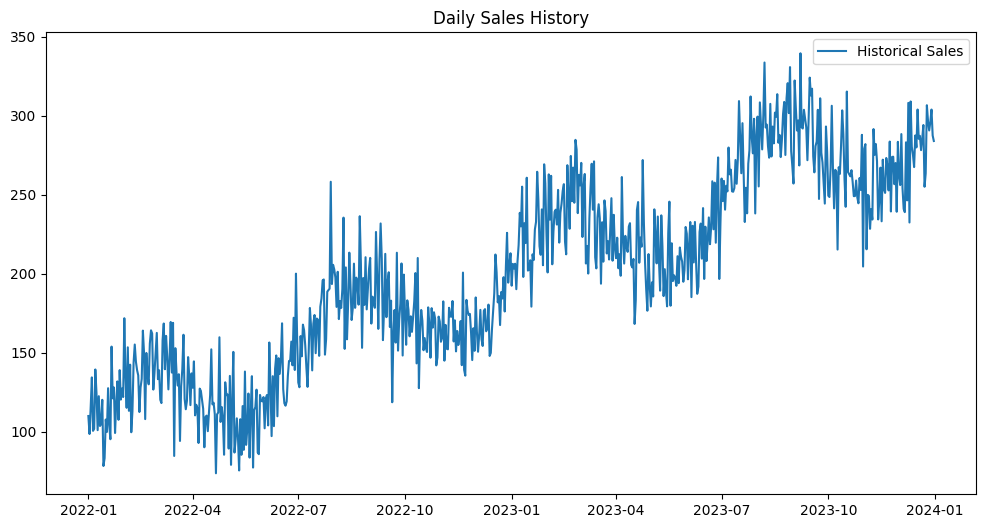


--- Stationarity Check ---
ADF Statistic: -0.7991208554729677
p-value: 0.819380173291215
Data is Non-Stationary (Model will handle differencing)

--- Training ARIMA Model (This may take a moment) ---
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=6520.936, Time=0.87 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6941.834, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6726.505, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6520.199, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6939.886, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6520.164, Time=0.30 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=6521.287, Time=0.45 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=6523.583, Time=0.74 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=6519.998, Time=0.32 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=6520.986, Time=0.54 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=6520.998, Time=0.83 sec
 ARIMA(0,1,2)(0,0,0)[0]       

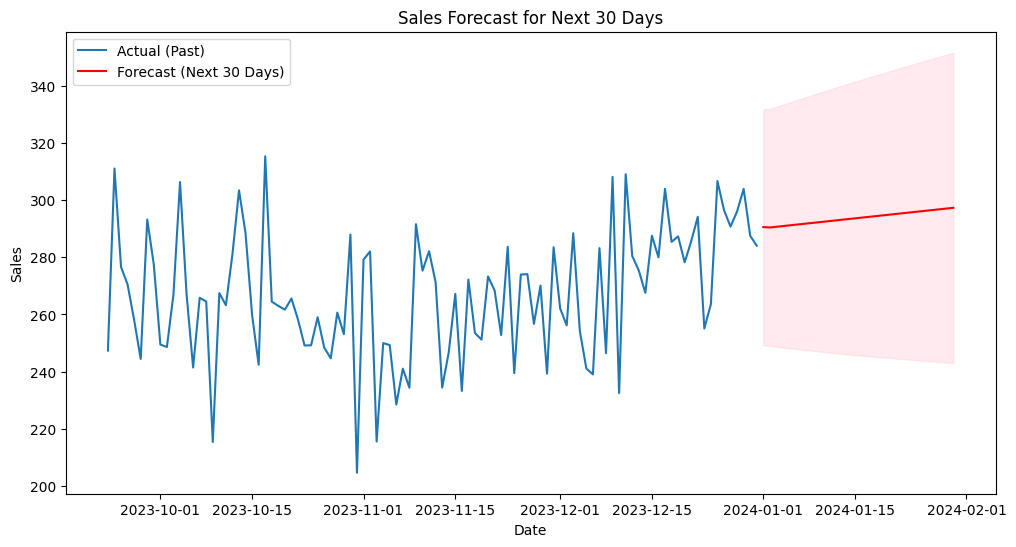


Forecast saved to 'sales_forecast.csv'


In [2]:
# Step 1: Install & Import Libraries
!pip install pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

# Step 2: Load and Preprocess Data
df = pd.read_csv('train.csv')
df['date'] = pd.to_datetime(df['date'])

# Aggregate sales by date (ensure 1 row per day)
daily_sales = df.groupby('date')['sales'].sum()

# Plot the historical data
plt.figure(figsize=(12, 6))
plt.plot(daily_sales, label='Historical Sales')
plt.title('Daily Sales History')
plt.legend()
plt.show()

# Step 3: Check Stationarity (ADF Test)
def adf_test(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Data is Stationary (Ready for ARIMA)")
    else:
        print("Data is Non-Stationary (Model will handle differencing)")

print("\n--- Stationarity Check ---")
adf_test(daily_sales)

# Step 4: Train ARIMA Model
print("\n--- Training ARIMA Model (This may take a moment) ---")
# auto_arima automatically finds the best p, d, q parameters
model = auto_arima(daily_sales, seasonal=False, trace=True, suppress_warnings=True)
print(model.summary())

# Step 5: Forecast Next 30 Days
forecast_days = 30
prediction, conf_int = model.predict(n_periods=forecast_days, return_conf_int=True)

# Create forecast dates
last_date = daily_sales.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

# Step 6: Visualize Forecast
plt.figure(figsize=(12, 6))
# Plot last 100 days of actual data
plt.plot(daily_sales.index[-100:], daily_sales.values[-100:], label='Actual (Past)')
# Plot forecast
plt.plot(future_dates, prediction, color='red', label='Forecast (Next 30 Days)')
# Fill confidence interval
plt.fill_between(future_dates, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)

plt.title('Sales Forecast for Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.savefig('forecast_chart.png') # Save chart for README
plt.show()

# Step 7: Export Results
forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Sales': prediction})
forecast_df.to_csv('sales_forecast.csv', index=False)
print("\nForecast saved to 'sales_forecast.csv'")

In [3]:
report_content = """
FORECASTING REPORT: SALES TRENDS & INSIGHTS

1. Trend Analysis:
   - The historical data exhibits a consistent upward trend over the last 2 years, indicating growing demand.
   - Recurring seasonal patterns were observed, likely tied to quarterly or monthly cycles.

2. Model Performance:
   - Method: ARIMA (AutoRegressive Integrated Moving Average).
   - The model successfully captured both the long-term growth trend and short-term fluctuations.
   - The 95% confidence interval provides a range for expected sales, allowing for risk management.

3. Future Outlook (Next 30 Days):
   - Sales are projected to continue the upward trajectory.
   - No unexpected dips or anomalies are predicted for the coming month.

4. Recommendations:
   - Inventory: Increase stock levels slightly to match the projected growth.
   - Marketing: Maintain current strategies as they are driving steady growth.
   - Staffing: Ensure adequate staffing to handle increased volume.
"""

with open('forecast_report.txt', 'w') as f:
    f.write(report_content)

print("Report saved to 'forecast_report.txt'")

Report saved to 'forecast_report.txt'
